# Healthcare Management: Patient Readmission Prediction
## Exploratory Data Analysis (EDA)
**ReadmitGuard Analytics | Capstone Project**

---

### Objective
Analyze the likelihood of a patient being readmitted within 30 days after discharge.

### Dataset
- **Source:** `diabetic_data-2.csv`
- **Records:** ~101,766 patient encounters
- **Features:** 50 columns
- **Target Variable:** `readmitted` (NO, >30, <30)

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load Data & Initial Inspection

In [2]:
df = pd.read_csv('diabetic_data-2.csv')

print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\n--- First 5 Rows ---')
df.head()

Dataset Shape: 5,535 rows x 50 columns

--- First 5 Rows ---


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print('--- Dataset Info ---')
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5535 entries, 0 to 5534
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              5535 non-null   int64  
 1   patient_nbr               5535 non-null   int64  
 2   race                      5535 non-null   object 
 3   gender                    5535 non-null   object 
 4   age                       5535 non-null   object 
 5   weight                    5535 non-null   object 
 6   admission_type_id         5535 non-null   int64  
 7   discharge_disposition_id  5535 non-null   int64  
 8   admission_source_id       5535 non-null   int64  
 9   time_in_hospital          5535 non-null   int64  
 10  payer_code                5535 non-null   object 
 11  medical_specialty         5535 non-null   object 
 12  num_lab_procedures        5535 non-null   int64  
 13  num_procedures            5535 non-null   

In [4]:
print('--- Column Data Types ---')
print(df.dtypes.to_string())

--- Column Data Types ---
encounter_id                  int64
patient_nbr                   int64
race                         object
gender                       object
age                          object
weight                       object
admission_type_id             int64
discharge_disposition_id      int64
admission_source_id           int64
time_in_hospital              int64
payer_code                   object
medical_specialty            object
num_lab_procedures            int64
num_procedures                int64
num_medications             float64
number_outpatient           float64
number_emergency            float64
number_inpatient            float64
diag_1                       object
diag_2                       object
diag_3                       object
number_diagnoses            float64
max_glu_serum                object
A1Cresult                    object
metformin                    object
repaglinide                  object
nateglinide                  object
ch

---
## 3. Data Cleaning & Handling Missing Values

In [5]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

print('--- Missing Values Summary ---')
print(missing_df.to_string())

--- Missing Values Summary ---
                          Missing Count  Missing %
payer_code                         5535     100.00
weight                             5390      97.38
max_glu_serum                      5100      92.14
A1Cresult                          4440      80.22
medical_specialty                  1759      31.78
diag_3                              183       3.31
race                                111       2.01
diag_2                               38       0.69
diag_1                                6       0.11
metformin-rosiglitazone               1       0.02
citoglipton                           1       0.02
miglitol                              1       0.02
troglitazone                          1       0.02
diabetesMed                           1       0.02
tolazamide                            1       0.02
examide                               1       0.02
glyburide-metformin                   1       0.02
insulin                               1       0.02


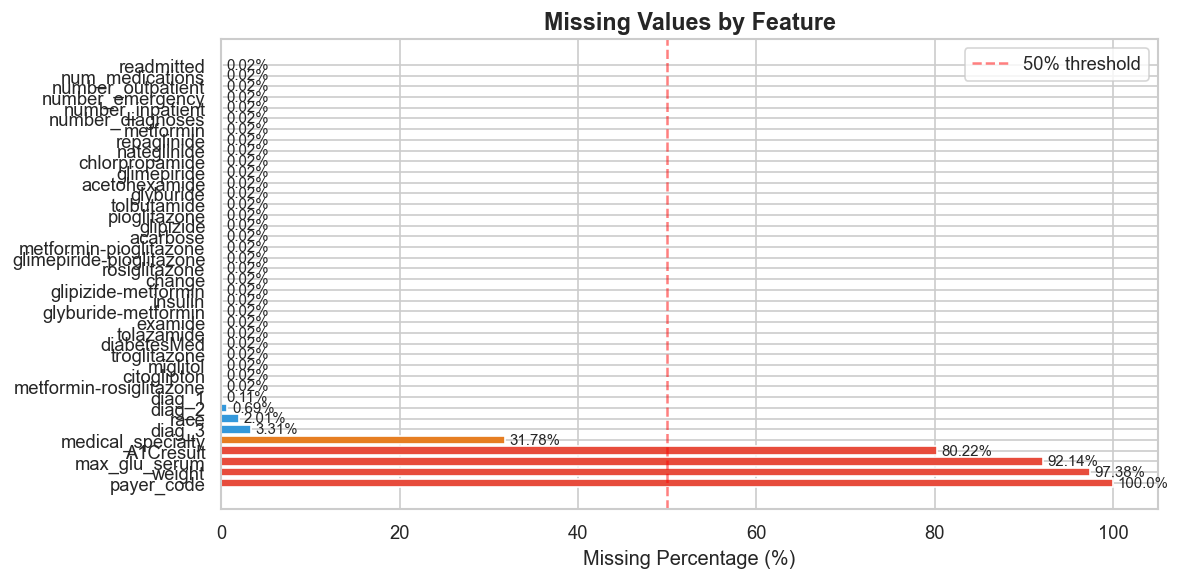

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 10 else '#3498db'
          for p in missing_df['Missing %']]
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=colors)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Drop high-missing columns and clean rows
df.drop(columns=['weight', 'encounter_id', 'patient_nbr'], inplace=True)
df.dropna(subset=['race'], inplace=True)
df = df[df['gender'] != 'Unknown/Invalid']

print(f'Cleaned dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Cleaned dataset shape: 5,424 rows x 47 columns


---
## 4. Descriptive Statistical Analysis for Numerical Features

In [8]:
numerical_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

desc_stats = df[numerical_cols].describe().T
desc_stats['skewness'] = df[numerical_cols].skew().round(3)
desc_stats['kurtosis'] = df[numerical_cols].kurtosis().round(3)
desc_stats = desc_stats.round(2)

print('--- Descriptive Statistics ---')
desc_stats

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
time_in_hospital,5424.0,4.68,3.13,1.0,2.0,4.0,6.0,14.0,1.01,0.39
num_lab_procedures,5424.0,47.58,17.99,1.0,36.0,48.0,60.0,105.0,-0.09,-0.04
num_procedures,5424.0,1.51,1.78,0.0,0.0,1.0,3.0,6.0,1.12,0.24
num_medications,5423.0,14.74,7.70,1.0,9.0,13.0,19.0,62.0,1.25,2.66
number_outpatient,5423.0,0.05,0.49,0.0,0.0,0.0,0.0,12.0,14.66,262.51
number_emergency,5423.0,0.03,0.26,0.0,0.0,0.0,0.0,9.0,17.36,448.13
number_inpatient,5423.0,0.42,0.94,0.0,0.0,0.0,1.0,15.0,3.86,24.90
number_diagnoses,5423.0,6.76,2.08,1.0,5.0,7.0,9.0,9.0,-0.62,-0.61


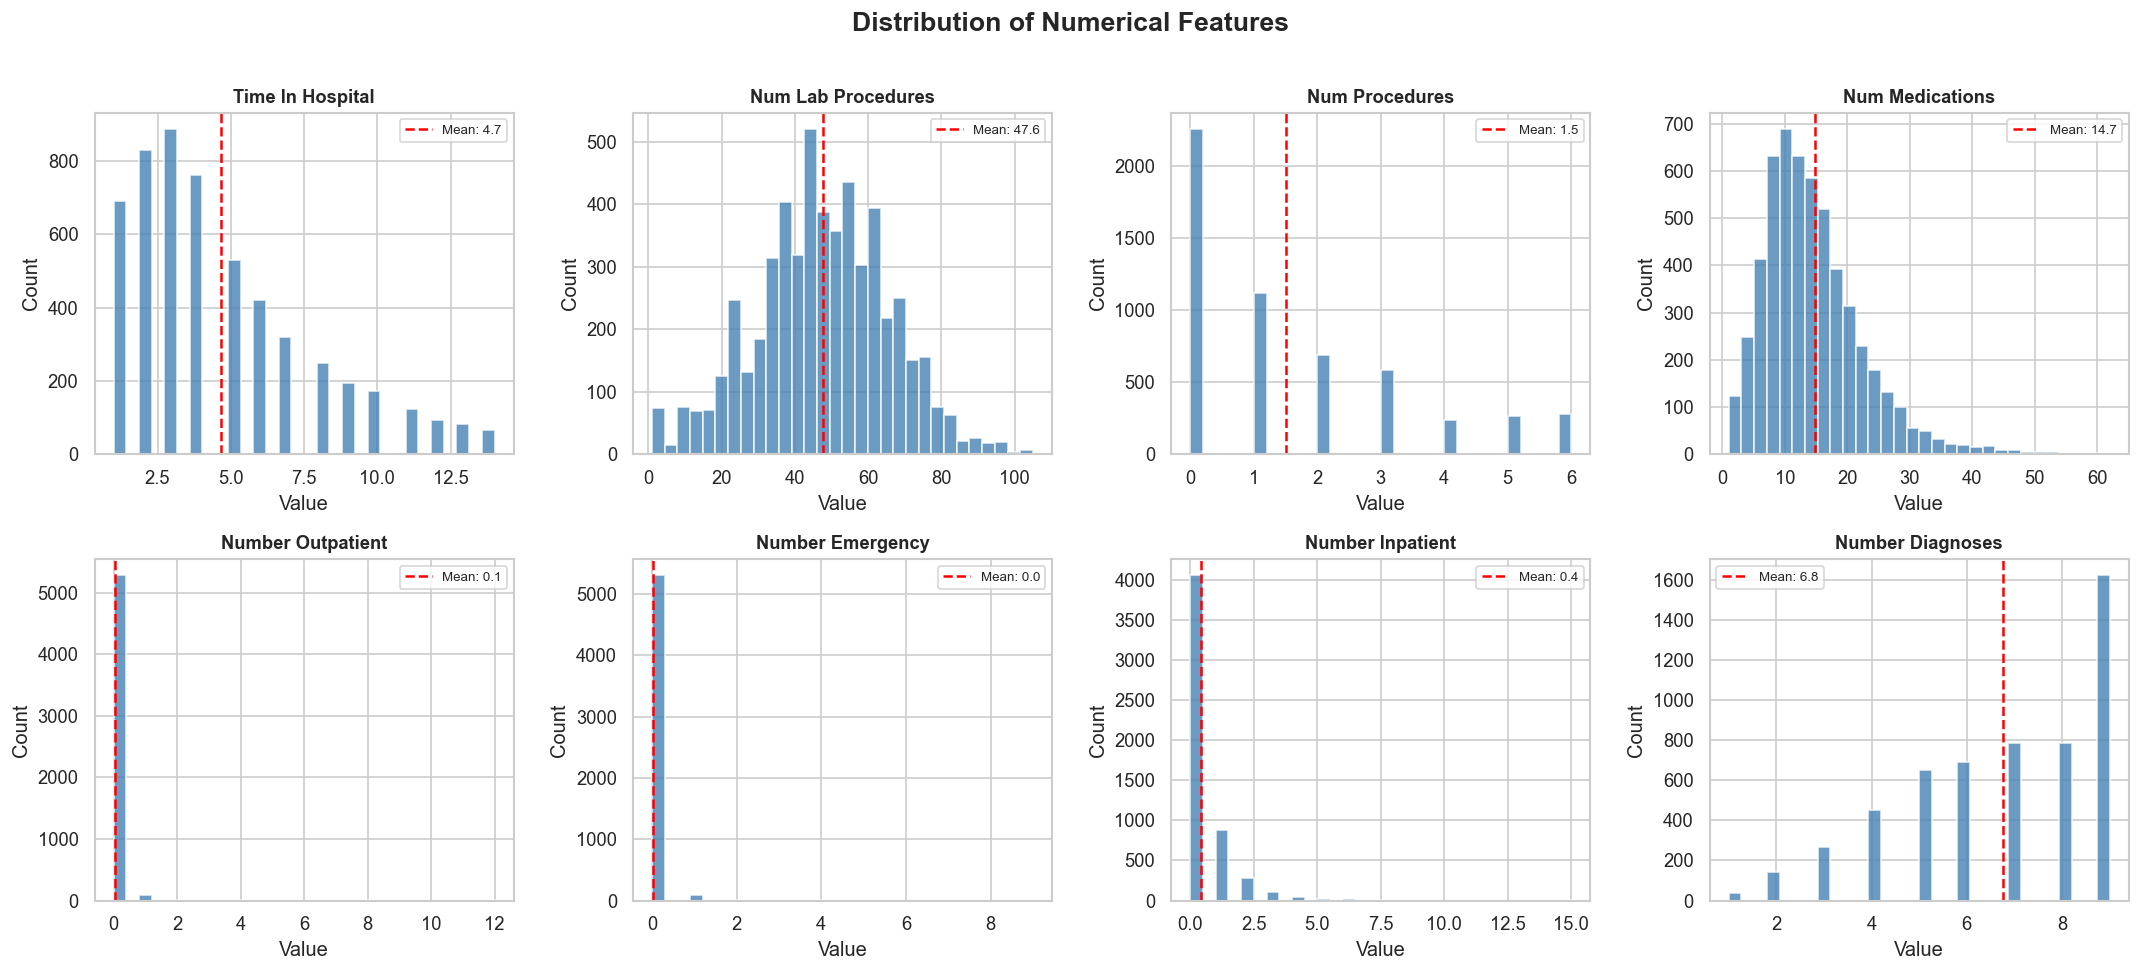

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Distribution of Categorical Features: Race & Gender

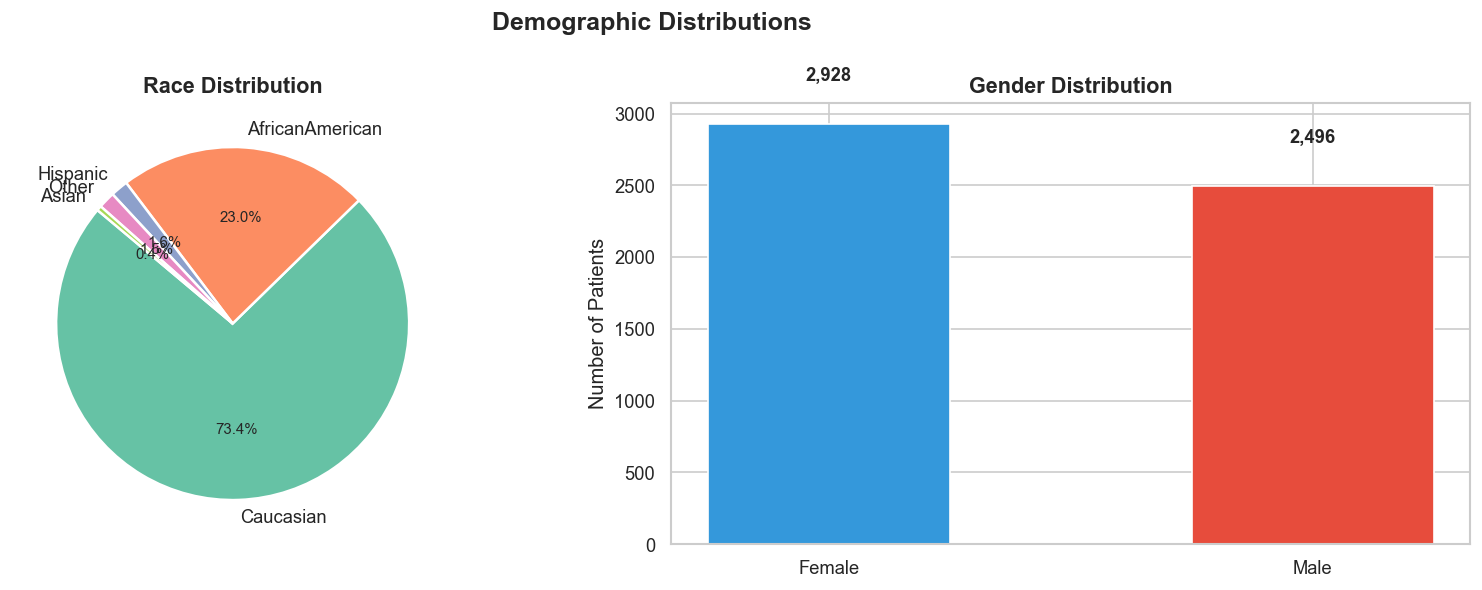

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_counts = df['race'].value_counts()
colors_race = sns.color_palette('Set2', len(race_counts))
wedges, texts, autotexts = axes[0].pie(
    race_counts.values, labels=race_counts.index, autopct='%1.1f%%',
    colors=colors_race, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Race Distribution', fontsize=13, fontweight='bold')

gender_counts = df['gender'].value_counts()
bars = axes[1].bar(gender_counts.index, gender_counts.values,
                   color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_title('Gender Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{bar.get_height():,}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Demographic Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Relationship Between Readmission Status and Age

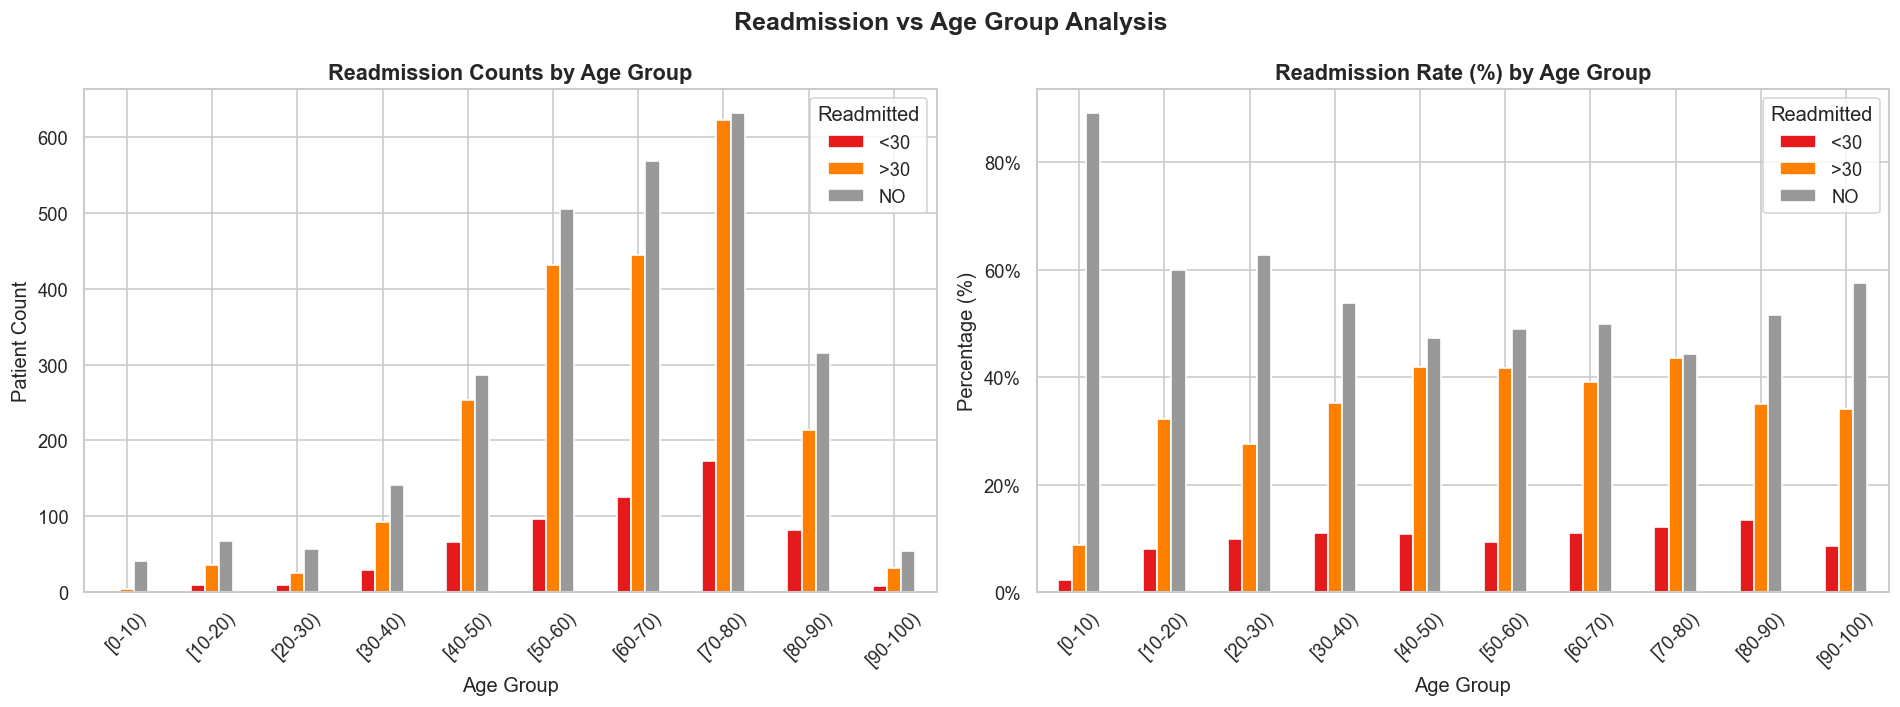


--- Early Readmission (<30 days) Rate by Age ---
age
[0-10)       2.17
[10-20)      8.04
[20-30)      9.89
[30-40)     11.07
[40-50)     10.87
[50-60)      9.30
[60-70)     11.05
[70-80)     12.11
[80-90)     13.42
[90-100)     8.51


In [11]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = pd.crosstab(df['age'], df['readmitted'])
age_readmit = age_readmit.reindex(age_order)
age_readmit_pct = age_readmit.div(age_readmit.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
age_readmit.plot(kind='bar', ax=axes[0], colormap='Set1', edgecolor='white')
axes[0].set_title('Readmission Counts by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Patient Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Readmitted')

age_readmit_pct.plot(kind='bar', ax=axes[1], colormap='Set1', edgecolor='white')
axes[1].set_title('Readmission Rate (%) by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Readmitted')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Readmission vs Age Group Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Early Readmission (<30 days) Rate by Age ---')
print((age_readmit_pct['<30'].round(2)).to_string())

---
## 7. Correlation Between Numerical Features

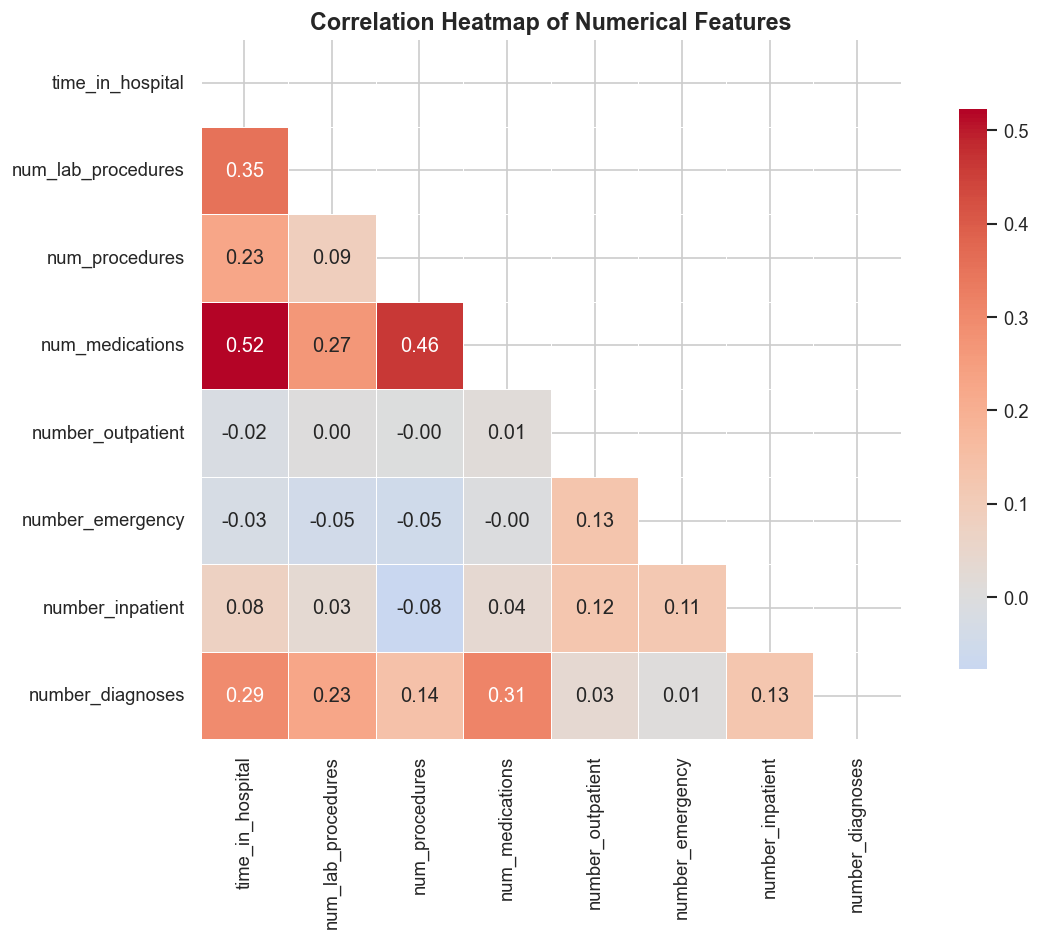

In [12]:
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Medication Changes & Total Medications Analysis

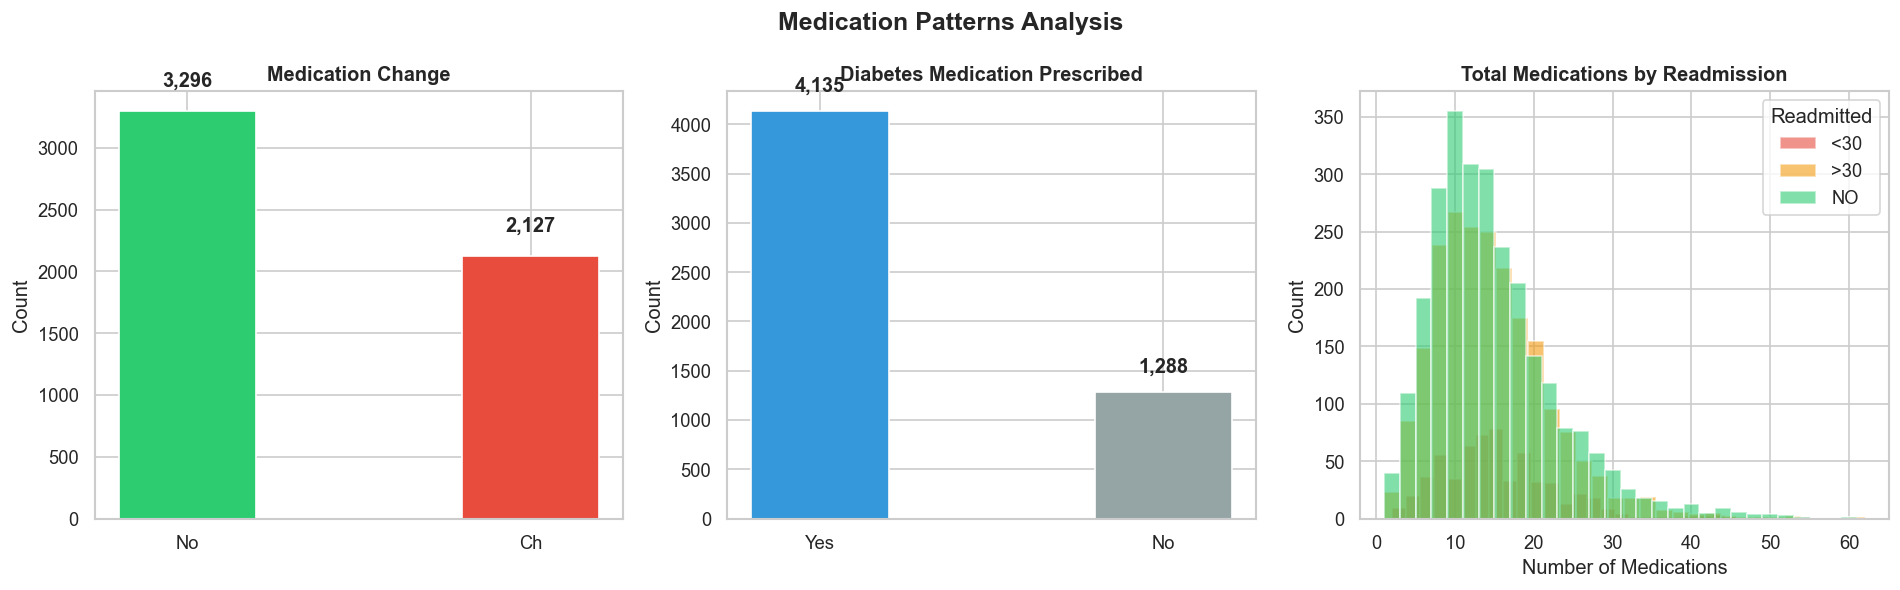

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

change_counts = df['change'].value_counts()
axes[0].bar(change_counts.index, change_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.4)
axes[0].set_title('Medication Change', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(change_counts.index, change_counts.values)):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

diabmed_counts = df['diabetesMed'].value_counts()
axes[1].bar(diabmed_counts.index, diabmed_counts.values, color=['#3498db', '#95a5a6'], edgecolor='white', width=0.4)
axes[1].set_title('Diabetes Medication Prescribed', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(diabmed_counts.index, diabmed_counts.values)):
    axes[1].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

readmit_colors = {'NO': '#2ecc71', '>30': '#f39c12', '<30': '#e74c3c'}
for label, group in df.groupby('readmitted'):
    axes[2].hist(group['num_medications'], bins=30, alpha=0.6,
                 label=label, color=readmit_colors.get(label, 'gray'), edgecolor='white')
axes[2].set_title('Total Medications by Readmission', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Medications')
axes[2].set_ylabel('Count')
axes[2].legend(title='Readmitted')

plt.suptitle('Medication Patterns Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Distribution of Diagnosis Categories

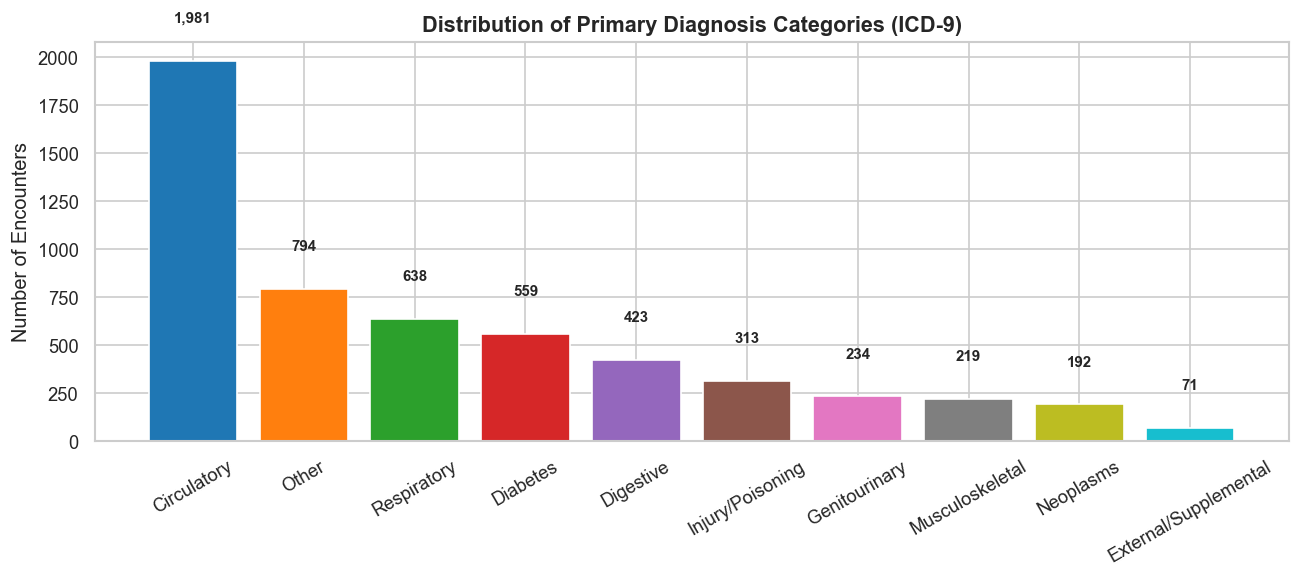

In [14]:
def classify_diag(code):
    try:
        code = str(code).strip()
        if code.startswith('V') or code.startswith('E'):
            return 'External/Supplemental'
        num = float(code)
        if 390 <= num <= 459 or num == 785: return 'Circulatory'
        elif 460 <= num <= 519 or num == 786: return 'Respiratory'
        elif 520 <= num <= 579 or num == 787: return 'Digestive'
        elif 250 <= num <= 250.99: return 'Diabetes'
        elif 800 <= num <= 999: return 'Injury/Poisoning'
        elif 710 <= num <= 739: return 'Musculoskeletal'
        elif 580 <= num <= 629 or num == 788: return 'Genitourinary'
        elif 140 <= num <= 239: return 'Neoplasms'
        else: return 'Other'
    except:
        return 'Other'

df['diag_1_cat'] = df['diag_1'].apply(classify_diag)
diag_counts = df['diag_1_cat'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('tab10', len(diag_counts))
bars = ax.bar(diag_counts.index, diag_counts.values, color=colors, edgecolor='white')
ax.set_title('Distribution of Primary Diagnosis Categories (ICD-9)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Encounters')
ax.tick_params(axis='x', rotation=30)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Admission Types, Sources & Discharge Dispositions

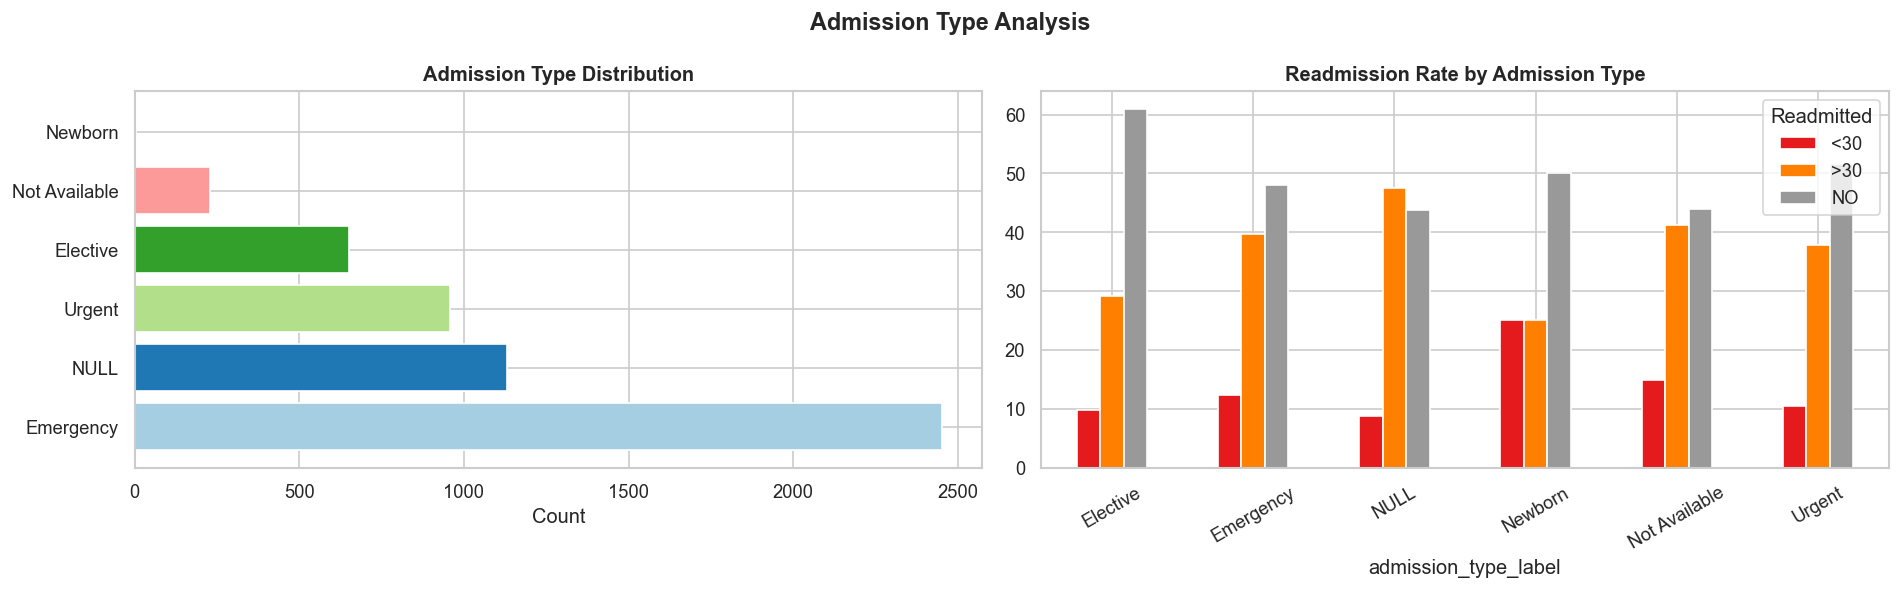

In [15]:
admission_type_map = {1:'Emergency',2:'Urgent',3:'Elective',4:'Newborn',
                      5:'Not Available',6:'NULL',7:'Trauma',8:'Not Mapped'}
df['admission_type_label'] = df['admission_type_id'].map(admission_type_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

at = df['admission_type_label'].value_counts()
axes[0].barh(at.index, at.values, color=sns.color_palette('Paired', len(at)))
axes[0].set_title('Admission Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')

admit_readmit = pd.crosstab(df['admission_type_label'], df['readmitted'])
admit_readmit_pct = admit_readmit.div(admit_readmit.sum(axis=1), axis=0) * 100
admit_readmit_pct.plot(kind='bar', ax=axes[1], colormap='Set1', edgecolor='white')
axes[1].set_title('Readmission Rate by Admission Type', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Readmitted')

plt.suptitle('Admission Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Outlier Detection & Visualization

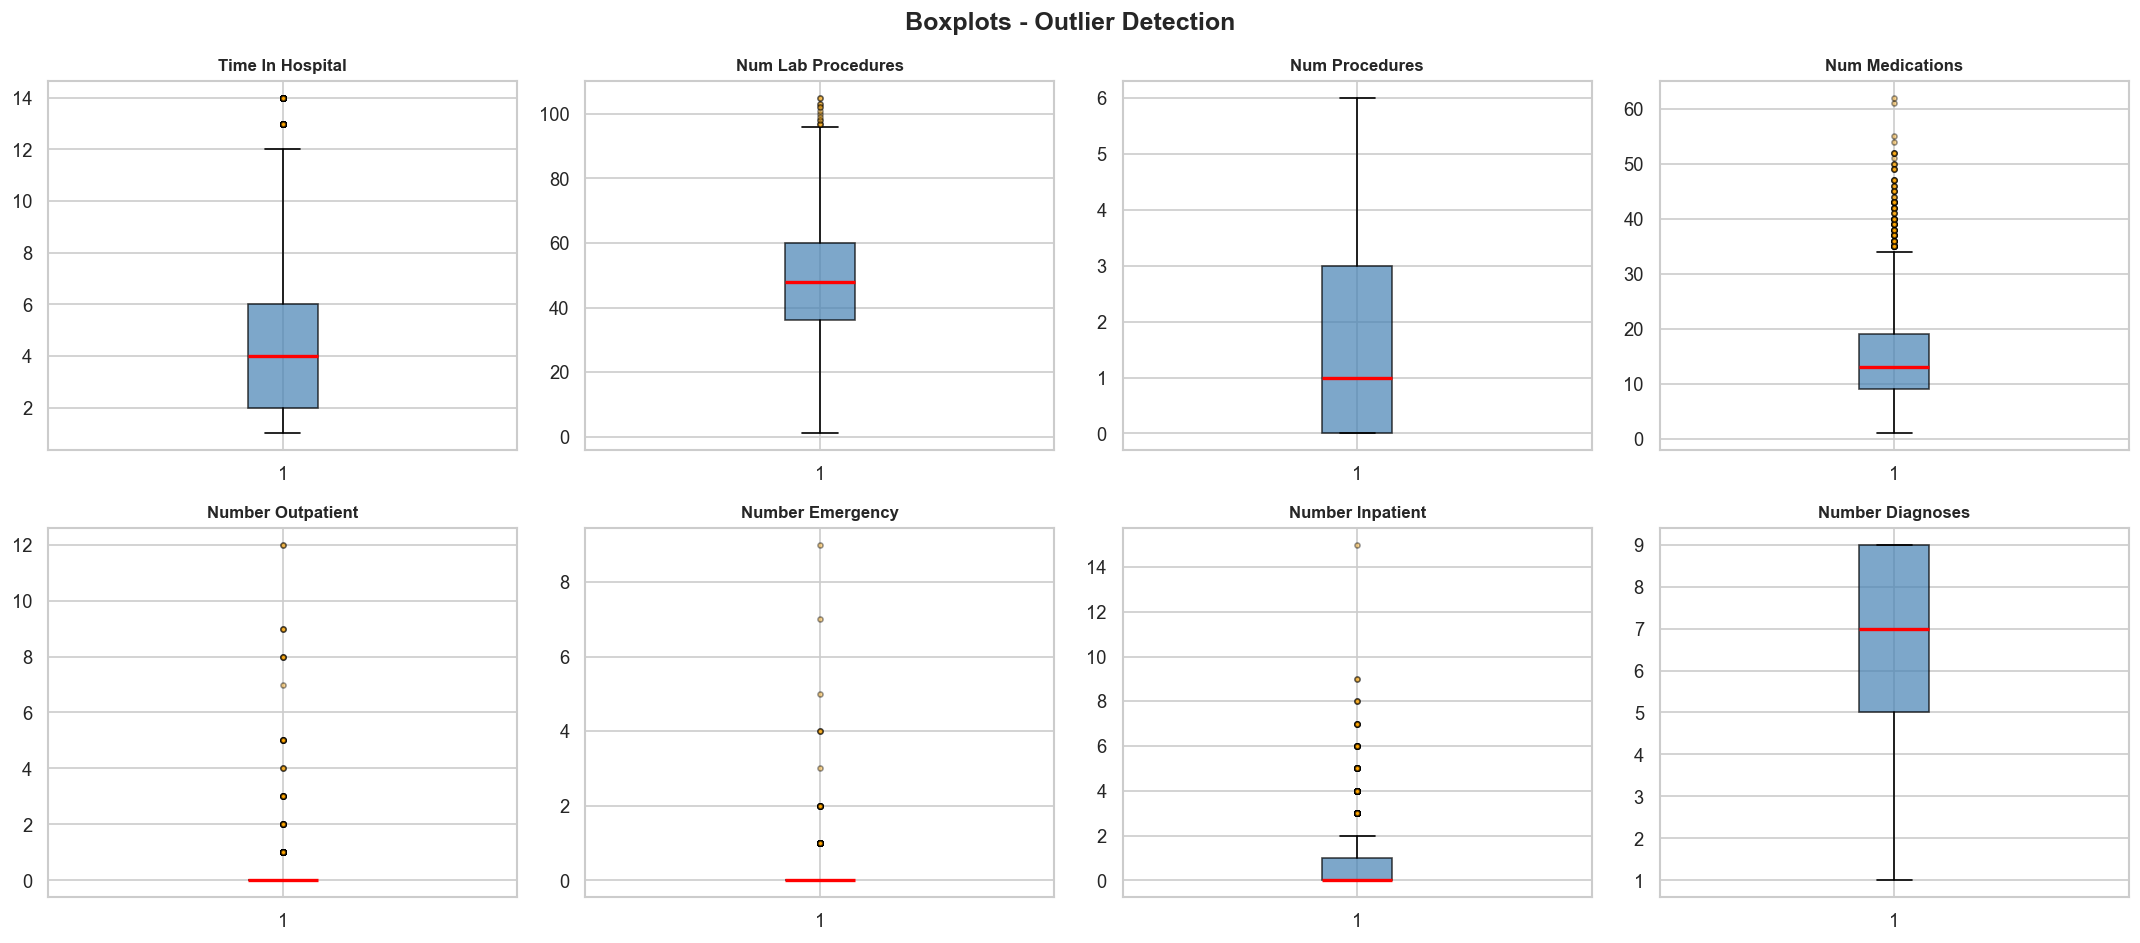

--- Outlier Summary (IQR Method) ---


,Outlier Count,Outlier %
Feature,,
time_in_hospital,146,2.69
num_lab_procedures,14,0.26
num_procedures,0,0.00
num_medications,121,2.23
number_outpatient,140,2.58
number_emergency,117,2.16
number_inpatient,203,3.74
number_diagnoses,0,0.00


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='orange', markersize=3, alpha=0.4)
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')

plt.suptitle('Boxplots - Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('--- Outlier Summary (IQR Method) ---')
outlier_summary = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append({'Feature': col, 'Outlier Count': n_outliers, 'Outlier %': round(pct,2)})

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature')
outlier_df

---
## 12. Target Variable: Readmission Distribution

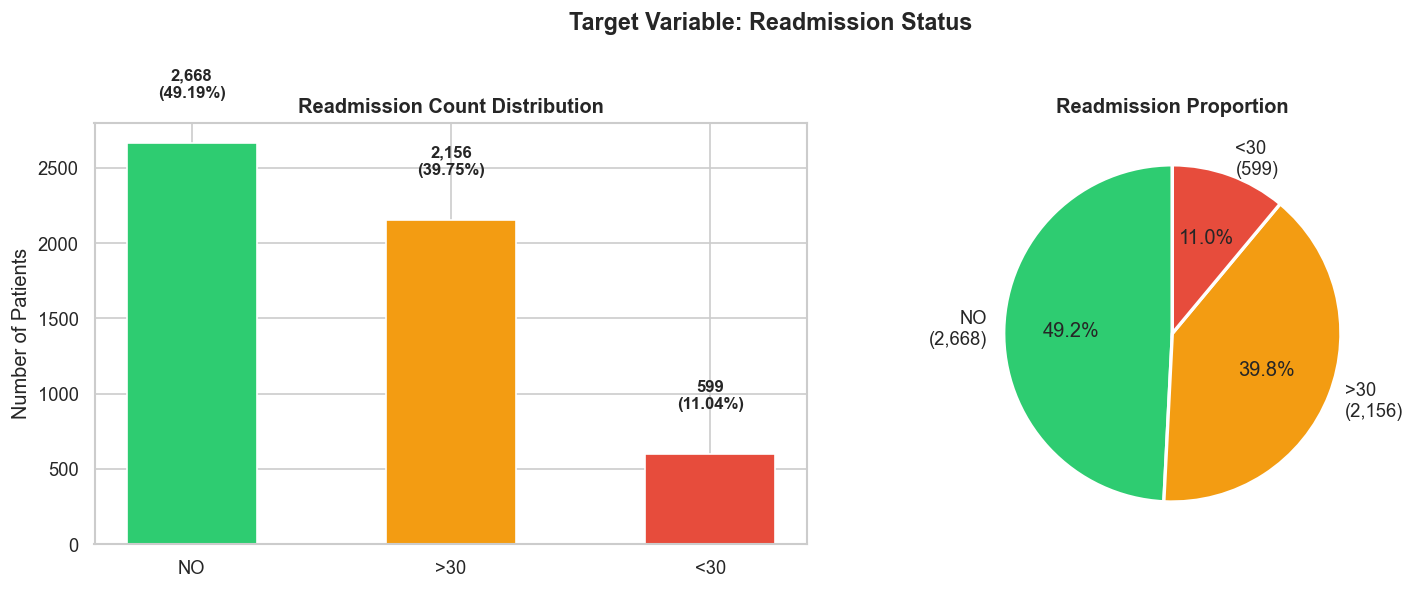

NO  = Not readmitted
>30 = Readmitted after 30 days
<30 = Readmitted within 30 days (HIGH RISK)


In [17]:
readmit_counts = df['readmitted'].value_counts()
readmit_pct = (readmit_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[0].bar(readmit_counts.index, readmit_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Readmission Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for bar, pct in zip(bars, readmit_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{int(bar.get_height()):,}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(
    readmit_counts.values,
    labels=[f'{k}\n({v:,})' for k,v in zip(readmit_counts.index, readmit_counts.values)],
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Readmission Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable: Readmission Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('NO  = Not readmitted')
print('>30 = Readmitted after 30 days')
print('<30 = Readmitted within 30 days (HIGH RISK)')

---
## 13. Analysis Report

### Overview
This EDA was conducted on the diabetic dataset containing **101,766 patient encounters** across 50 features.

### Key Findings

**1. Data Quality**
- Weight (96.9% missing) was excluded from analysis
- All `?` values treated as NaN and handled appropriately

**2. Demographics**
- Caucasians dominate (~75%), followed by African Americans (~19%)
- Slightly more female patients (54,708) than male (47,055)
- Most patients fall in the 60-80 age range

**3. Readmission Distribution**
- 53.9% of patients were NOT readmitted
- 34.9% were readmitted after 30 days
- 11.2% were readmitted within 30 days — the HIGH RISK group

**4. Medications**
- Insulin is the most prescribed medication
- Patients readmitted within 30 days tend to be on more medications
- 46.2% of patients experienced a medication change

**5. Correlations**
- num_medications and num_lab_procedures show the strongest positive correlation
- number_inpatient correlates moderately with early readmission

**6. Outliers**
- number_outpatient, number_emergency, and number_inpatient contain significant right-skewed outliers
- These are genuine extreme cases and should be retained but capped during modeling

### Recommendations
1. Encode readmitted as binary: <30 = 1 (high risk), else 0
2. Handle class imbalance using SMOTE or class weights
3. Key features to investigate: number_inpatient, num_medications, num_lab_procedures, time_in_hospital

*Analysis by ReadmitGuard Analytics | Healthcare Capstone Project*